# Automated Evaluation

In [ ]:
# Run this on Remote Jupyter Book.

import os

os.getcwd()
os.chdir("/root/OtakuLab")

## Load Batch Inference Results

In [1]:
from pathlib import Path
from typing_extensions import TypedDict
import json

class InferenceItem(TypedDict):
    model: str
    neutral: str
    output: str
    character: str
    subset: str

class NeutralEvalItem(TypedDict):
    subset: str
    neutral: str

BATCH_INFERENCE_FILE = Path("./outputs/batch_run_result.jsonl")
NEUTRAL_EVAL_FILE = Path("./data/neutral_sentences_eval.jsonl")

neutral_to_subset: dict[str, str] = {}
with open(NEUTRAL_EVAL_FILE, "r", encoding="utf-8-sig") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        neutral_item: NeutralEvalItem = json.loads(line)
        neutral_text = str(neutral_item["neutral"]).strip()
        subset = str(neutral_item["subset"]).strip()

        if neutral_text in neutral_to_subset and neutral_to_subset[neutral_text] != subset:
            raise ValueError(f"发现同一 neutral 对应多个 subset: {neutral_text[:40]}...")
        neutral_to_subset[neutral_text] = subset

batch_inference_items: list[InferenceItem] = []
missing_subset_count = 0

with open(BATCH_INFERENCE_FILE, "r", encoding="utf-8") as f:
    lines = f.readlines()
    for line in lines:
        raw_item = json.loads(line.strip())
        neutral_text = str(raw_item["neutral"]).strip()
        subset = neutral_to_subset.get(neutral_text)

        if subset is None:
            missing_subset_count += 1
            subset = "UNKNOWN"

        output_text = raw_item["output"]
        output_text = output_text.split("</think>")[1].strip() if "</think>" in output_text else output_text

        inference_item: InferenceItem = {
            "model": raw_item["model"],
            "neutral": neutral_text,
            "output": output_text,
            "character": raw_item["character"],
            "subset": subset,
        }
        batch_inference_items.append(inference_item)

if missing_subset_count > 0:
    raise ValueError(
        f"有 {missing_subset_count} 条 batch 样本未匹配到 subset，请检查 neutral_sentences_eval.jsonl 与 batch_run_result.jsonl 是否一致。"
    )

print(f"Loaded {len(batch_inference_items)} items with subset labels.")

Loaded 7200 items with subset labels.


## Degeneration Detection

### Detect Potential Repetition Loops

In [ ]:
import re
from collections import Counter

import pandas as pd


def repetition_features(text: str) -> dict:
    text = (text or "").strip()
    text = text.replace("...", ", ")  # 将省略号替换为逗号，避免干扰重复检测
    char_len = len(text)
    if char_len == 0:
        return {
            "char_len": 0,
            "token_count": 0,
            "unique_ratio": 0.0,
            "max_char_run": 0,
            "max_token_run": 0,
            "top_token_ratio": 0.0,
            "loop_score": 1.0,
        }

    # 中文语料下用“中英文词块 + 标点”做粗粒度 token，能较好捕捉“鬼子？鬼子？”这类重复
    tokens = re.findall(r"[A-Za-z0-9_]+|[\u4e00-\u9fff]+|[^\w\s]", text)
    token_count = len(tokens)

    if token_count == 0:
        return {
            "char_len": char_len,
            "token_count": 0,
            "unique_ratio": 0.0,
            "max_char_run": 0,
            "max_token_run": 0,
            "top_token_ratio": 0.0,
            "loop_score": 1.0,
        }

    unique_ratio = len(set(tokens)) / token_count

    # 最大字符连续重复，例如“哈哈哈哈哈”
    max_char_run = max((len(m.group(0)) for m in re.finditer(r"(.)\1+", text)), default=1)

    # 最大 token 连续重复，例如“鬼子 ? 鬼子 ? ...”中的“鬼子”重复段
    max_token_run = 1
    cur = 1
    for i in range(1, token_count):
        if tokens[i] == tokens[i - 1]:
            cur += 1
            if cur > max_token_run:
                max_token_run = cur
        else:
            cur = 1

    counts = Counter(tokens)
    top_token_ratio = counts.most_common(1)[0][1] / token_count

    # 简单退化分：越接近 1 越可能是死循环/复读
    loop_score = (
        0.45 * (1.0 - unique_ratio)
        + 0.35 * min(max_token_run / 12.0, 1.0)
        + 0.20 * min(top_token_ratio / 0.35, 1.0)
    )

    return {
        "char_len": char_len,
        "token_count": token_count,
        "unique_ratio": float(unique_ratio),
        "max_char_run": int(max_char_run),
        "max_token_run": int(max_token_run),
        "top_token_ratio": float(top_token_ratio),
        "loop_score": float(loop_score),
    }


def is_repetition_loop(feat: dict) -> bool:
    # 任一规则命中即判定为可疑，阈值偏保守，优先召回
    return (
        feat["loop_score"] >= 0.5
        or feat["max_token_run"] >= 8
        or (feat["token_count"] >= 30 and feat["unique_ratio"] <= 0.22)
        or feat["top_token_ratio"] >= 0.5
    )


rows = []
for item in batch_inference_items:
    if item["model"] in ["BaselineA", "BaselineC", "BaselineB"]:
        continue

    feat = repetition_features(item["output"])
    rows.append({
        "model": item["model"],
        "character": item["character"],
        "neutral": item["neutral"],
        "output": item["output"],
        **feat,
        "is_loop": is_repetition_loop(feat),
    })

df_loop = pd.DataFrame(rows)

print("=== Repetition Loop Detection Summary ===")
summary = (
    df_loop.groupby("model", as_index=False)
    .agg(
        total=("is_loop", "size"),
        loop_cases=("is_loop", "sum"),
        avg_loop_score=("loop_score", "mean"),
    )
)
summary["loop_ratio"] = (summary["loop_cases"] / summary["total"]).round(4)
summary = summary.sort_values(["loop_ratio", "avg_loop_score"], ascending=False)
print(summary.to_string(index=False))

TOP_K = 10
print(f"\n=== Top {TOP_K} Worst Loop Cases per Model ===")
for model_name, g in df_loop.groupby("model"):
    worst = g.sort_values("loop_score", ascending=False).head(TOP_K)
    print(f"\nModel: {model_name}")
    for _, row in worst.iterrows():
        flag = "LOOP" if row["is_loop"] else "CHECK"
        print(
            f"  [{flag}] loop_score={row['loop_score']:.3f}, "
            f"uniq={row['unique_ratio']:.3f}, max_tok_run={int(row['max_token_run'])}, "
            f"top_tok={row['top_token_ratio']:.3f}, char={row['character']}"
        )
        print(f"    Neutral: {row['neutral']}")
        print(f"    Output : {row['output'][:220]}{'...' if len(row['output']) > 220 else ''}")
        print("-" * 80)

## Style Consistency Evaluation

### Load Model

In [4]:
from pathlib import Path
from typing import Tuple, Dict, List
from tqdm import tqdm

from transformers import AutoModel, AutoTokenizer
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from tokenizers import Tokenizer

import numpy as np
import torch.nn as nn
import torch
import os

BACKBONE_PATH = str(Path('../Models/chinese-roberta-wwm-ext').resolve())
CHECKPOINT_PATH = Path('outputs/evaluate/style-classifier')

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Model definition
class CharacterStyleClassifier(nn.Module):
    def __init__(self, backbone_name: str, embed_dim: int = 768, proj_dim: int = 256, num_roles: int = 6, dropout: float = 0.4):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name, output_hidden_states=False)
        self.hidden_size = self.backbone.config.hidden_size
        assert self.hidden_size == embed_dim, f"Backbone hidden_size {self.hidden_size} != embed_dim {embed_dim}"

        self.proj = nn.Sequential(
            nn.Linear(self.hidden_size, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(proj_dim, num_roles)

    def mean_pooling(self, last_hidden_state, attention_mask):
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        sum_hidden = torch.sum(last_hidden_state * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        mean_pooled = sum_hidden / sum_mask
        return mean_pooled

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        last_hidden = out.last_hidden_state
        sent_emb = self.mean_pooling(last_hidden, attention_mask)
        proj = self.proj(sent_emb)
        logits = self.classifier(proj)
        return logits, proj
    
def load_checkpoint(path: str, device='cpu') -> Tuple[nn.Module, 'Tokenizer', LabelEncoder, Dict[str, np.ndarray]]:
    tokenizer = AutoTokenizer.from_pretrained(path)
    with open(os.path.join(path, 'label_encoder.json'), 'r', encoding='utf-8') as f:
        le_json = json.load(f)
    le = LabelEncoder()
    le.classes_ = np.array(le_json['classes'])

    # use the saved backbone
    # 1. 从 config 获取 hidden_size
    backbone_hidden = AutoModel.from_pretrained(path).config.hidden_size
    # 2. 直接从 `path` 初始化模型，这将加载微调后的 backbone
    model = CharacterStyleClassifier(path, embed_dim=backbone_hidden, proj_dim=256, num_roles=len(le.classes_))
    # 3. 加载 head 权重
    chk = torch.load(os.path.join(path, 'head.pt'), map_location=device)
    model.proj.load_state_dict(chk['proj_state'])
    model.classifier.load_state_dict(chk['classifier_state'])
    # 4. 加载 centers
    centers_npz = np.load(os.path.join(path, 'role_centers.npz'))
    role_centers = {k: centers_npz[k] for k in centers_npz.files}
    return model.to(device), tokenizer, le, role_centers

@torch.no_grad()
def compute_role_centers(model: nn.Module, dataloader: DataLoader, label_encoder: LabelEncoder, device='cpu') -> Dict[str, np.ndarray]:
    model.eval()
    accum: Dict[int, List[np.ndarray]] = {}
    for batch in tqdm(dataloader, desc="Computing centers"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].cpu().numpy()
        _, embeddings = model(input_ids=input_ids, attention_mask=attention_mask)
        emb_np = embeddings.detach().cpu().numpy()
        for lbl, e in zip(labels, emb_np):
            accum.setdefault(int(lbl), []).append(e)
    role_centers = {}
    for lbl, vecs in accum.items():
        avg = np.mean(np.stack(vecs, axis=0), axis=0)
        role_name = label_encoder.inverse_transform([lbl])[0]
        role_centers[role_name] = avg
    return role_centers


def get_style_score(model: nn.Module, tokenizer, text: str, role_center: np.ndarray, device='cpu', max_length=128) -> float:
    model.eval()
    enc = tokenizer(text, truncation=True, max_length=max_length, padding='max_length', return_tensors='pt')
    input_ids = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)
    with torch.no_grad():
        _, emb = model(input_ids=input_ids, attention_mask=attention_mask)
        emb_np = emb.detach().cpu().numpy()[0]
    num = float(np.dot(emb_np, role_center))
    den = float(np.linalg.norm(emb_np) * np.linalg.norm(role_center) + 1e-9)
    return num / den

model, tokenizer, label_encoder, role_centers = load_checkpoint(str(CHECKPOINT_PATH), device)


libgomp: Invalid value for environment variable OMP_NUM_THREADS
/root/miniconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]

libgomp: Invalid value for environment variable OMP_NUM_THREADS


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

### Execute Evaluation

In [5]:
import pandas as pd

# Calculate style scores for each item
results = []

for item in tqdm(batch_inference_items, desc="Evaluating Style"):
    character = item['character']
    output_text = item['output']
    
    if character not in role_centers:
        print(f"Warning: Character '{character}' not found in role centers. Skipping.")
        continue

    center = role_centers[character]
    score = get_style_score(model, tokenizer, output_text, center, device=device)
    
    results.append({
        **item,
        "style_score": score,
    })

# Save detailed results
df_results = pd.DataFrame(results)

style_summary = (
    df_results.groupby(["subset", "model"], as_index=False)
    .agg(
        avg_style_score=("style_score", "mean"),
        n=("style_score", "size"),
    )
    .sort_values(["subset", "model"])
    .round(4)
)

print("\nStyle Consistency Scores:")
print(style_summary.to_string(index=False))

Evaluating Style: 100%|██████████| 8400/8400 [00:57<00:00, 145.54it/s]


Style Consistency Scores:
subset           model  avg_style_score   n
   挑战性       BaselineA           0.6492 432
   挑战性       BaselineB           0.7066 432
   挑战性       BaselineC           0.9460 432
   挑战性      ModelDPOv1           0.6881 432
   挑战性 ModelDPOv1.r100           0.7063 432
   挑战性 ModelDPOv1.r105           0.6890 432
   挑战性       Modelv4.3           0.6397 432
  日常对话       BaselineA           0.7312 768
  日常对话       BaselineB           0.7448 768
  日常对话       BaselineC           0.9651 768
  日常对话      ModelDPOv1           0.7157 768
  日常对话 ModelDPOv1.r100           0.7801 768
  日常对话 ModelDPOv1.r105           0.7535 768
  日常对话       Modelv4.3           0.6646 768


## Semantic Preservation Evaluation

### Load Model

In [6]:
from sentence_transformers import SentenceTransformer, util

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

# MODEL_PATH = "../Models/bge-large-zh-v1.5"
MODEL_PATH = "/root/autodl-tmp/bge-large-zh-v1.5"
semantic_model = SentenceTransformer(MODEL_PATH)

def compute_semantic_similarity(neutral_text, stylized_text):
    """
    计算两个句子的语义相似度 (0 ~ 1)
    """
    # BGE 建议在作为 Query 时添加指令，但作为对称相似度对比，直接编码通常效果已足够好
    # 或者是为两边都添加 "为这个句子生成表示以用于检索相关文章：" (视具体版本文档而定)
    # 对于 STS (Semantic Textual Similarity) 任务，v1.5 通常可以直接使用。
    
    embeddings = semantic_model.encode([neutral_text, stylized_text], normalize_embeddings=True)
    
    # 计算余弦相似度
    similarity = util.cos_sim(embeddings[0], embeddings[1])
    return similarity.item()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /root/autodl-tmp/bge-large-zh-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Execute Evaluation

In [7]:
# Calculate semantic scores for each item
for item in tqdm(results, desc="Evaluating Semantic"):
    neutral_text = item['neutral']
    stylized_text = item['output']
    
    # Compute similarity
    score = compute_semantic_similarity(neutral_text, stylized_text)
    
    # Store result
    item['semantic_score'] = score

# === 计算 H-Score 与有效风格得分 ===
SEM_THRESHOLD = 0.75  # 语义门槛

for item in results:
    style_score = item.get('style_score', 0.0)
    sem_score = item.get('semantic_score', 0.0)
    
    # H-Score (harmonic mean)
    h_score = (2 * style_score * sem_score) / (style_score + sem_score + 1e-9)
    
    # 语义门控后的有效风格分
    penalty_factor = 1.0 if sem_score > SEM_THRESHOLD else 0.1
    penalized_style = style_score * penalty_factor
    
    item['h_score'] = h_score
    item['valid_style_score'] = penalized_style

# Aggregate results
model_metrics = {}

for item in results:
    m_name = item['model']
    char_name = item['character']
    sem = item['semantic_score']
    sty = item['style_score']
    h = item['h_score']
    vsty = item['valid_style_score']
    
    if m_name not in model_metrics:
        model_metrics[m_name] = {
            'semantic': [],
            'style': [],
            'h_score': [],
            'valid_style': [],
            'per_char': {}
        }
    
    # total
    model_metrics[m_name]['semantic'].append(sem)
    model_metrics[m_name]['style'].append(sty)
    model_metrics[m_name]['h_score'].append(h)
    model_metrics[m_name]['valid_style'].append(vsty)
    
    # per-character (只对语义分保留细粒度，若需要可以扩展)
    if char_name not in model_metrics[m_name]['per_char']:
        model_metrics[m_name]['per_char'][char_name] = []
    model_metrics[m_name]['per_char'][char_name].append(sem)

# Update the DataFrame with the new scores
df_results = pd.DataFrame(results)

# Print Report
print(f"\nSemantic Preservation + Style Scores(SEM_THRESHOLD={SEM_THRESHOLD}):")
print("=" * 80)
for m_name, metrics in model_metrics.items():
    avg_sem = np.mean(metrics['semantic'])
    avg_style = np.mean(metrics['style'])
    avg_h = np.mean(metrics['h_score'])
    avg_vsty = np.mean(metrics['valid_style'])
    
    print(f"Model: {m_name}")
    sorted_chars = sorted(metrics['per_char'].keys())
    for char_name in sorted_chars:
        scores = metrics['per_char'][char_name]
        avg_char_sem = np.mean(scores)
        print(f"  - Character: {char_name:<10} | Sem: {avg_char_sem:.4f} (n={len(scores)})")
    
    print(f"  >> Avg Semantic: {avg_sem:.4f}")
    print(f"  >> Avg Style  : {avg_style:.4f}")
    print(f"  >> Avg H-Score: {avg_h:.4f}")
    print(f"  >> Avg Valid Style: {avg_vsty:.4f}")
    print("-" * 80)

subset_summary = (
    df_results.groupby(['subset', 'model'], as_index=False)
    .agg(
        semantic_score=('semantic_score', 'mean'),
        style_score_raw=('style_score', 'mean'),
        h_score=('h_score', 'mean'),
        valid_style_score=('valid_style_score', 'mean'),
        n=('model', 'size'),
    )
    .sort_values(['subset', 'valid_style_score'], ascending=[True, False])
    .round(4)
)

print("\n=== By Subset ===")
print(subset_summary.to_string(index=False))

Evaluating Semantic: 100%|██████████| 8400/8400 [02:12<00:00, 63.40it/s]


Semantic Preservation + Style Scores(SEM_THRESHOLD=0.75):
Model: Modelv4.3
  - Character: 凉宫春日       | Sem: 0.8900 (n=150)
  - Character: 孙悟空        | Sem: 0.8424 (n=150)
  - Character: 李云龙        | Sem: 0.8681 (n=150)
  - Character: 沐雪         | Sem: 0.9041 (n=150)
  - Character: 神里绫华       | Sem: 0.9260 (n=150)
  - Character: 胡桃         | Sem: 0.8956 (n=150)
  - Character: 谢尔顿        | Sem: 0.9025 (n=150)
  - Character: 钟离         | Sem: 0.9444 (n=150)
  >> Avg Semantic: 0.8966
  >> Avg Style  : 0.6556
  >> Avg H-Score: 0.7189
  >> Avg Valid Style: 0.6096
--------------------------------------------------------------------------------
Model: ModelDPOv1
  - Character: 凉宫春日       | Sem: 0.8818 (n=150)
  - Character: 孙悟空        | Sem: 0.7949 (n=150)
  - Character: 李云龙        | Sem: 0.8461 (n=150)
  - Character: 沐雪         | Sem: 0.8970 (n=150)
  - Character: 神里绫华       | Sem: 0.9126 (n=150)
  - Character: 胡桃         | Sem: 0.8811 (n=150)
  - Character: 谢尔顿        | Sem: 0.8725 (n=150)


### Generate 2D Scatter Plot/Comprehensive Metrics Table

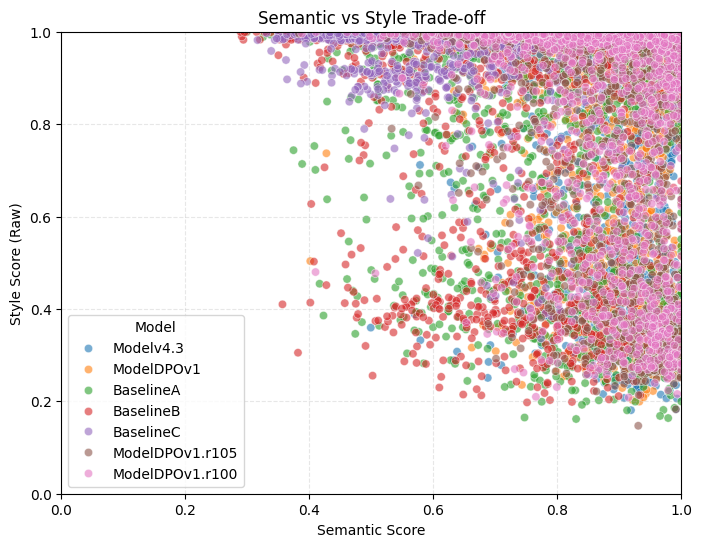


Leaderboard by subset:


,subset,model,semantic_score,style_score_raw,h_score,valid_style_score,n
3,挑战性,ModelDPOv1,0.9015,0.6881,0.7435,0.6387,432
5,挑战性,ModelDPOv1.r105,0.9073,0.6890,0.7442,0.6354,432
4,挑战性,ModelDPOv1.r100,0.8935,0.7063,0.7474,0.6257,432
6,挑战性,Modelv4.3,0.9231,0.6397,0.7156,0.6194,432
0,挑战性,BaselineA,0.8177,0.6492,0.6759,0.4809,432
1,挑战性,BaselineB,0.7457,0.7066,0.6845,0.4060,432
2,挑战性,BaselineC,0.6289,0.9460,0.7460,0.1879,432
11,日常对话,ModelDPOv1.r100,0.8473,0.7801,0.7806,0.6351,768
12,日常对话,ModelDPOv1.r105,0.8606,0.7535,0.7676,0.6300,768
10,日常对话,ModelDPOv1,0.8651,0.7157,0.7460,0.6129,768


,model,semantic_score,style_score_raw,h_score,valid_style_score,n
5,ModelDPOv1.r105,0.8774,0.7303,0.7592,0.6319,1200
4,ModelDPOv1.r100,0.8639,0.7536,0.7687,0.6317,1200
3,ModelDPOv1,0.8782,0.7057,0.7451,0.6222,1200
6,Modelv4.3,0.8966,0.6556,0.7189,0.6096,1200
0,BaselineA,0.7697,0.7017,0.6879,0.4069,1200
1,BaselineB,0.6962,0.7311,0.6643,0.3219,1200
2,BaselineC,0.6147,0.9582,0.7396,0.1941,1200


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

FIGURE_SAVE_PATH = Path("./LaTex/figures/Figure5.1.v2.pdf")
FIGURE_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

# 图表 3.1：二维散点图 (Semantic vs Style)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_results, x="semantic_score", y="style_score", hue="model", alpha=0.6)
plt.xlabel("Semantic Score")
plt.ylabel("Style Score (Raw)")
plt.title("Semantic vs Style Trade-off")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(title="Model")
plt.grid(True, linestyle="--", alpha=0.3)
plt.savefig(FIGURE_SAVE_PATH)
plt.show()

# 表格 3.2：整体综合指标表
df_leaderboard = (
    df_results.groupby("model", as_index=False)
    .agg(
        semantic_score=("semantic_score", "mean"),
        style_score_raw=("style_score", "mean"),
        h_score=("h_score", "mean"),
        valid_style_score=("valid_style_score", "mean"),
        n=("model", "size"),
    )
    .sort_values(by=["valid_style_score"], ascending=False)
    .round(4)
)

# 表格 3.3：按 subset 分组的综合指标表
df_leaderboard_by_subset = (
    df_results.groupby(["subset", "model"], as_index=False)
    .agg(
        semantic_score=("semantic_score", "mean"),
        style_score_raw=("style_score", "mean"),
        h_score=("h_score", "mean"),
        valid_style_score=("valid_style_score", "mean"),
        n=("model", "size"),
    )
    .sort_values(by=["subset", "valid_style_score"], ascending=[True, False])
    .round(4)
)

print("\nLeaderboard by subset:")
display(df_leaderboard_by_subset)

df_leaderboard

### Export Evaluation Results

In [9]:
output_path = "./outputs/evaluate_result.jsonl"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(model_metrics, f, ensure_ascii=False, indent=4)

### Analyze Worst Semantic Scores

In [10]:
pd.set_option('display.max_colwidth', 200)

top_n = 5

print(f"\n=== Worst Semantic Cases per Model (Top {top_n}) ===")
for m_name in df_results['model'].unique():
    subset = df_results[df_results['model'] == m_name]
    # Sort ascending by semantic, so worst are at top
    worst_cases = subset.sort_values(by='semantic_score', ascending=True).head(top_n)
    
    print(f"\nModel: {m_name}")
    for idx, row in worst_cases.iterrows():
        print(f"  [Sem: {row['semantic_score']:.4f} | Char: {row['character']}]")
        print(f"    Neutral: {row['neutral']}")
        print(f"    Output : {row['output']}")
        print("-" * 60)


=== Worst Semantic Cases per Model (Top 5) ===

Model: Modelv4.3
  [Sem: 0.3817 | Char: 神里绫华]
    Neutral: 你现在在干嘛?
    Output : <think>思考: 作为神里绫华，她会用亲切且充满活力的语调询问对方的状态，并通过适当的语气词和问号体现温柔与关怀。
------------------------------------------------------------
  [Sem: 0.4992 | Char: 李云龙]
    Neutral: 这只鱼看着就感觉好吃
    Output : 肯定是吃了！肯定好吃！
------------------------------------------------------------
  [Sem: 0.5601 | Char: 孙悟空]
    Neutral: 当然，这种活动能让我释放一下压力，感觉爽快
    Output : 自然。这等闲事，我老孙也得来个痛快！
------------------------------------------------------------
  [Sem: 0.5678 | Char: 神里绫华]
    Neutral: 你以为你能打败我吗？放马过来吧！
    Output : 你竟敢挑战我？那就来吧！旅行者，让我们看看谁才是真正的强者！
------------------------------------------------------------
  [Sem: 0.5702 | Char: 李云龙]
    Neutral: 当然，这种活动能让我释放一下压力，感觉爽快
    Output : 当然能啊！我就是个喜欢玩闹的小子，打打杀杀才痛快呢
------------------------------------------------------------

Model: ModelDPOv1
  [Sem: 0.4016 | Char: 神里绫华]
    Neutral: 你现在在干嘛?
    Output : <think>思考: 作为理性且充满活力的大大小姐，她会用温和亲切的语气询问对方的状态，并通过

## LLM-as-a-Judge

### Define Model Service

In [2]:
import os
from dataclasses import dataclass, field
from typing import Optional, Dict, Any, Sequence, Tuple, Iterable

from openai import OpenAI
from openai.types.chat import ChatCompletionMessageParam as ChatMsgParam
from dotenv import load_dotenv

load_dotenv()  # 从 .env 文件加载环境变量

# === 配置项 ===
DEFAULT_API_KEY = os.getenv("OPENAI_API_KEY", "sk-PLACEHOLDER")
DEFAULT_BASE_URL = os.getenv("OPENAI_BASE_URL", "https://dashscope.aliyuncs.com/compatible-mode/v1")
DEFAULT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "deepseek-v3.2")

DEFAULT_SYSTEM_PROMPT = """你是一位顶级的计算语言学专家和角色扮演对话评估者。你的任务是评估基于大语言模型生成的“角色风格转化”文本。
请在仔细阅读 [原始中性文本]、[目标角色设定] 后，对提供的 [生成文本] 进行三个独立维度的 1-5 分评估。不要偏袒字数较长的文本，评估必须严格基于以下客观标准：

[Evaluation Dimensions]
1. 意图对齐度 (Intent Preservation)
- 评估目标：生成的文本是否忠实地传达了 [原始中性文本] 的核心信息和交际目的？允许为了契合角色风格而进行合理的修辞扩展，但不允许偏离核心话题或丢失关键信息。
- 1分：完全改变了原意，或者丢失了核心交际目的。
- 3分：基本保留了原意，但存在一些不影响大局的信息遗漏或轻微偏移。
- 5分：完美传达了原意，任何修辞的增加都服务于原意图的表达，没有发生话题偏移。

2. 对话连贯与自然度 (Conversational Relevance)
- 评估目标：生成的文本在真实的对话语境中是否自然、得体？它是否对原话做出了恰当的反应，还是突兀地引入了与当前对话无关的背景知识或世界观设定（即“信息过度暴露”）？
- 1分：极不自然，包括以下任一情况：强行引入与当前对话无关的角色背景、他人名字或世界观设定（比如在日常话题上升到国家层面）；生成多角色对话剧本或包含括号旁白/动作描写；使用Markdown格式（**粗体**、*斜体*）
- 3分：相对自然，但有些许冗余，或者在日常对话中显得有些用力过猛。
- 5分：极其自然。完美符合当前对话的语境，提供的信息量恰到好处，没有突兀的设定堆砌。如果出现角色背景或世界观设定（通常较少使用），必须完美融入对话语境，且不影响自然流畅。

3. 角色表现力 (Persona Consistency)
- 评估目标：文本的语气、语用习惯（词汇选择、句法结构、情感倾向）是否与 [目标角色设定] 高度一致？
- 1分：完全看不出是该角色，或者只是生硬地贴了几个标签。
- 3分：有该角色的影子，但可能不够生动，或者有轻微的“破局（Out-of-Character）”感。
- 5分：形神兼备。不仅口癖正确，而且句法和情感深度完美契合该角色的心理画像。

[Output Format]
请严格按照以下 JSON 格式输出，每个 reasoning 控制在 75 字以内：
{
  "intent_score": <1-5>,
  "intent_reasoning": "<...>",
  "relevance_score": <1-5>,
  "relevance_reasoning": "<...>",
  "persona_score": <1-5>,
  "persona_reasoning": "<...>"
}
"""

character_profile_template = """角色名称: {character_name}
性格标签: {pragmatic_styles}
语言偏好: {signature_rules}
"""

prompt_template = "[角色信息]: {character_profile}\n\n[原始中性文本]: {neutral_sentence}\n\n[生成文本]: {generated_sentence}"

ConversationTurn = Tuple[str, Optional[str]]
"""表示一次对话轮次：(user_message, assistant_reply)。assistant_reply 可为 None。"""


def _build_messages(
    prompt: str,
    history: Optional[Sequence[ConversationTurn]] = None,
    system_prompt: Optional[str] = None,
) -> list[ChatMsgParam]:
    messages: list[ChatMsgParam] = []

    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})

    if history:
        for user_msg, assistant_msg in history:
            messages.append({"role": "user", "content": user_msg})
            if assistant_msg:
                messages.append({"role": "assistant", "content": assistant_msg})

    messages.append({"role": "user", "content": prompt})
    return messages


@dataclass(slots=True)
class SimpleLLMClient:
    """极简 LLM 封装：初始化固定模型，提供 ask() 返回字符串。"""

    model: str = DEFAULT_MODEL
    api_key: str = DEFAULT_API_KEY
    base_url: Optional[str] = DEFAULT_BASE_URL
    system_prompt: Optional[str] = DEFAULT_SYSTEM_PROMPT
    extra_headers: Optional[Dict[str, str]] = None
    _client: OpenAI = field(init=False, repr=False)

    def __post_init__(self) -> None:
        self._client = OpenAI(
            api_key=self.api_key,
            base_url=self.base_url,
            default_headers=self.extra_headers if self.extra_headers else None,
        )

    def _consume_stream(self, stream_resp: Iterable[Any]) -> str:
        """消费流式响应，拼接内容。"""
        chunks: list[str] = []
        for chunk in stream_resp:
            choices = getattr(chunk, "choices", None)
            if not choices:
                continue
            delta = getattr(choices[0], "delta", None)
            if delta and getattr(delta, "content", None):
                chunks.append(delta.content)
        return "".join(chunks)

    def ask(
        self,
        prompt: str,
        history: Optional[Sequence[ConversationTurn]] = None,
        *,
        temperature: float = 0.7,
        top_p: float = 0.9,
        max_tokens: Optional[int] = None,
        **kwargs: Any,
    ) -> str:
        """生成回复。

        参数：
            prompt: 当前用户输入。
            history: 可选的历史 [(user, assistant), ...]，assistant 允许为 None。
            temperature/max_tokens/stream/kwargs：直接透传给 OpenAI Chat Completion。
        返回：
            模型回复的纯文本（若响应为空则返回空字符串）。
        """
        messages = _build_messages(
            prompt=prompt,
            history=history,
            system_prompt=self.system_prompt,
        )

        response = self._client.chat.completions.create(
            model=self.model,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
            top_p=top_p,
            stream=False,
            extra_body={"enable_thinking": False},
            **kwargs,
        )

        choice = response.choices[0]
        if hasattr(choice, "message") and getattr(choice.message, "content", None):
            return choice.message.content  # type: ignore[return-value]
        # 兼容历史版本/异常情况
        return getattr(choice, "text", "")


# 初始化一个通用实例，供 Notebook 其他单元直接调用
llm = SimpleLLMClient()

### Construct Character Style Vectors

In [3]:
PRAGMATIC_DIR = Path("./outputs/style/semantic/prag_vectors")

CHARACTER_TO_PRAG_FILE = {
    "沐雪": "muice.jsonl",
    "神里绫华": "ayaka.jsonl",
    "钟离": "zhongli.jsonl",
    "胡桃": "hutao.jsonl",
    "凉宫春日": "haruhi.jsonl",
    "李云龙": "liyunlong.jsonl",
    "谢尔顿": "sheldon.jsonl",
    "孙悟空": "wukong.jsonl"
}

class RawPragmaticItem(TypedDict):
    prompt: str
    response: str
    pragmatic_styles: list[dict[str, float]]

class SemanticItem(TypedDict):
    response: str
    semantic_tags: list[str]

def read_semantic_jsonl_file(jsonl_file: Path, top_k: int = 5) -> list[SemanticItem]:
    items: list[SemanticItem] = []
    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            raw_item: RawPragmaticItem = json.loads(line)
            score_map: dict[str, float] = {}
            for vec in raw_item.get("pragmatic_styles", []):
                score_map.update(vec)

            top_items = sorted(
                score_map.items(),
                key=lambda item: float(item[1]),
                reverse=True,
            )[:top_k]
            semantic_tags = [key for key, _ in top_items]
            items.append({"response": raw_item["response"], "semantic_tags": semantic_tags})

    return items

In [4]:
from collections import defaultdict

class CharacterProfile(TypedDict):
    character: str
    semantic_tags: list[str]
    structural_metrics: dict[str, float]
    signature_rules: list[str]

def compute_character_top_semantic_tags(character: str, top_k: int = 5) -> list[str]:
    """
    对齐 13 notebook 的 compute_style_statistics 统计口径：
    按标签 activation_rate（出现样本占比）排序，并用 avg_probability 作为并列打破规则。
    """
    prag_file_name = CHARACTER_TO_PRAG_FILE.get(character)
    if prag_file_name is None:
        raise ValueError(f"{character} 的角色标签不存在！")

    prag_file = PRAGMATIC_DIR / prag_file_name
    if not prag_file.exists():
        raise ValueError(f"{character} 的角色标签不存在！")

    score_sums: dict[str, float] = defaultdict(float)
    score_counts: dict[str, int] = defaultdict(int)
    activation_counts: dict[str, int] = defaultdict(int)
    total_samples = 0

    with open(prag_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            raw_item: RawPragmaticItem = json.loads(line)
            pragmatic_styles = raw_item.get("pragmatic_styles", [])
            if not pragmatic_styles:
                continue

            total_samples += 1
            activated_in_sample: set[str] = set()

            for vec in pragmatic_styles:
                for tag, score in vec.items():
                    score_sums[tag] += float(score)
                    score_counts[tag] += 1
                    activated_in_sample.add(tag)

            for tag in activated_in_sample:
                activation_counts[tag] += 1

    if not score_sums or total_samples == 0:
        return []

    tag_records = [
        (
            tag,
            activation_counts[tag] / total_samples,
            score_sums[tag] / score_counts[tag],
        )
        for tag in score_sums.keys()
        if score_counts[tag] > 0
    ]
    tag_records.sort(key=lambda x: (x[1], x[2]), reverse=True)
    return [tag for tag, _, _ in tag_records[:top_k]]

muice_profile = CharacterProfile(
    character="沐雪",
    semantic_tags=compute_character_top_semantic_tags("沐雪"),
    structural_metrics={
        "mdd": 0.2201,
        "verb_noun_ratio": 0.8084,
        "question_ratio": 0.8631,
        "imperative_ratio": 0.4648,
        "fragment_ratio": 0.7843,
        "marker_density": 0.4233,
    },
    signature_rules=[
        "Lexical cues: 喵, 沐沐, AI, ~, 沐雪, 恼, 女孩子, ⭐, 聊天, 唔, 呀, 可爱, 答, 不行, 笨蛋, 雪雪, 直播, 脸红, 睡觉, www, 谢谢, 变态, 骂, 嘛, 杂鱼",
        "Punctuation tendencies: ..., ⭐, ?!, multi-!, ♪, ❤",
    ],
)

ayaka_profile = CharacterProfile(
    character="神里绫华",
    semantic_tags=compute_character_top_semantic_tags("神里绫华"),
    structural_metrics={
        "mdd": 0.4102,
        "verb_noun_ratio": 0.0841,
        "question_ratio": 0.1381,
        "imperative_ratio": 0.1808,
        "fragment_ratio": 0.2789,
        "marker_density": 0.0668,
    },
    signature_rules=[
        "Lexical cues: 稻妻国, 神里家, 稻妻, 大小姐, 家族, 传统, 神, 奉行, 眼狩令, 当地, 美丽, 社, 舞蹈, 茶道, 神社, 文化, 剑术, 眼, 祭典, 旅行者, 美食, 继承, 历史, 神明, 派蒙",
        "Punctuation tendencies: ⋯, ...",
    ],
)

zhongli_profile = CharacterProfile(
    character="钟离",
    semantic_tags=compute_character_top_semantic_tags("钟离"),
    structural_metrics={
        "mdd": 0.3458,
        "verb_noun_ratio": 0.0006,
        "question_ratio": 0.3969,
        "imperative_ratio": 0.2680,
        "fragment_ratio": 0.7750,
        "marker_density": 0.0,
    },
    signature_rules=[
        "Lexical cues: 岩石, 岩, 璃月, 璃, 力, 契约, 炼金术, 月, 盐, 帝君, 魔神, 操控, 岩王, 王, 封印, 元素, 大陆, 七星, 客卿, 岩元素, 大地, 学问, 力量, 凝光, 易事",
        "Punctuation tendencies: ...",
    ],
)

hutao_profile = CharacterProfile(
    character="胡桃",
    semantic_tags=compute_character_top_semantic_tags("胡桃"),
    structural_metrics={
        "mdd": 1.0,
        "verb_noun_ratio": 0.3783,
        "question_ratio": 0.4059,
        "imperative_ratio": 0.3408,
        "fragment_ratio": 0.7260,
        "marker_density": 1.0,
    },
    signature_rules=[
        "Lexical cues: 往生堂, 嘿嘿, 嘻嘻, 堂主, 宝藏, 可是, 哎呀呀, 哦哦哦, 诗歌, 神秘, 惊喜, 谜题, 胡桃, 有趣, 灵魂, 哈哈哈, 秘密, 哇, 奇妙, 意想不到, 隐藏, 亡灵, 生死, 冒险, 巫师",
        "Punctuation tendencies: ..., ♪",
    ],
)

haruhi_profile = CharacterProfile(
    character="凉宫春日",
    semantic_tags=compute_character_top_semantic_tags("凉宫春日"),
    structural_metrics={
        "mdd": 0.4891,
        "verb_noun_ratio": 0.3785,
        "question_ratio": 0.7901,
        "imperative_ratio": 0.2811,
        "fragment_ratio": 1.0,
        "marker_density": 0.4223,
    },
    signature_rules=[
        "Lexical cues: SOS, 阿虚, 社团, 团, 哼, 学校, 事件, 朝比奈, 超自然, 文化祭, 吸引, 古泉, 创意, 实玖瑠, 与众不同, 创新, 电影, 束缚, 凉宫, 主题, 外星人, 学姐, 举办, 奇怪, 加入",
        "Punctuation tendencies: ..., ·",
    ],
)

liyunlong_profile = CharacterProfile(
    character="李云龙",
    semantic_tags=compute_character_top_semantic_tags("李云龙"),
    structural_metrics={
        "mdd": 0.4897,
        "verb_noun_ratio": 0.5131,
        "question_ratio": 1.0,
        "imperative_ratio": 1.0,
        "fragment_ratio": 0.9085,
        "marker_density": 0.0229,
    },
    signature_rules=[
        "Lexical cues: 鬼子, 咱们, 中国人, 敌人, 不怕, 侵略者, 军人, 保卫, 兄弟们, 李云龙, 别, 狠狠, 政委, 部队, 小子, 打仗, 独立, 祖国, 中国, 国家, 日本, 屁, 牺牲, 教训, 楚",
        "Punctuation tendencies: ?!, ...",
    ],
)

wukong_profile = CharacterProfile(
    character="孙悟空",
    semantic_tags=["energetic", "playful", "irritable", "loyal", "confident"],  # 替换分类器错误分类
    structural_metrics={
        "mdd": 0.3997,
        "verb_noun_ratio": 0.5705,
        "question_ratio": 0.7424,
        "imperative_ratio": 0.3252,
        "fragment_ratio": 0.5560,
        "marker_density": 0.1086,
    },
    signature_rules=[
        "Lexical cues: 师父, 老孙, 孙, 老, 哩, 莫, 甚么, 妖精, 怪, 儿, 等, 呆子, 甚, 不曾, 罢, 菩萨, 教, 不知, 若是, 泼, 却, 棍, 如今, 这般, 云",
    ],
)

sheldon_profile = CharacterProfile(
    character="谢尔顿",
    semantic_tags=compute_character_top_semantic_tags("谢尔顿"),
    structural_metrics={
        "mdd": 0.2660,
        "verb_noun_ratio": 0.0,
        "question_ratio": 0.5998,
        "imperative_ratio": 0.4395,
        "fragment_ratio": 0.6591,
        "marker_density": 0.4862,
    },
    signature_rules=[
        "Lexical cues: 伦纳德, 佩妮, 智力, 莱纳德, 必须, 科学, 逻辑, 令, 指出, 实验, 绝非, 已, 卓越, 霍华德, 概念, 至关重要, 类, 量子, 项, 着迷, 恪守, 毫无, 因此, 此, 理论",
    ],
)

In [5]:
import json
import re

# 建立角色名到 Profile 的映射（与上文角色配置保持一致）
NAME_TO_PROFILE = {
    "沐雪": muice_profile,
    "神里绫华": ayaka_profile,
    "钟离": zhongli_profile,
    "胡桃": hutao_profile,
    "凉宫春日": haruhi_profile,
    "李云龙": liyunlong_profile,
    "孙悟空": wukong_profile,
    "谢尔顿": sheldon_profile,
}

def get_char_meta(name):
    """从 CharacterProfile 中提取元数据并组装为最新模板所需的 character_profile 文本。"""
    profile = NAME_TO_PROFILE.get(name)
    if profile is None:
        raise ValueError(f"Unknown character profile: {name}")

    semantic_tags = ", ".join(profile.get("semantic_tags", []))
    signature_rules = " | ".join(profile.get("signature_rules", []))

    character_profile = character_profile_template.format(
        character_name=profile["character"],
        pragmatic_styles=semantic_tags,
        signature_rules=signature_rules,
    )
    return {"character_profile": character_profile}


def _extract_json_block(response: str) -> str:
    content = (response or "").strip()

    if "```json" in content:
        content = content.split("```json", 1)[1]
        content = content.split("```", 1)[0].strip()
    elif "```" in content:
        parts = content.split("```")
        if len(parts) >= 2:
            content = parts[1].strip()

    start_idx = content.find("{")
    end_idx = content.rfind("}")
    if start_idx == -1 or end_idx == -1 or end_idx <= start_idx:
        raise ValueError(f"No JSON structure found in response: {response[:120]}...")

    return content[start_idx:end_idx + 1]


def _repair_json_common_errors(json_str: str) -> str:
    repaired = json_str
    # 常见脏格式：数字后多了一个引号，如 "relevance_score": 4",
    repaired = re.sub(r'(:\s*[-+]?\d+(?:\.\d+)?)"\s*,', r'\1,', repaired)
    repaired = re.sub(r'(:\s*[-+]?\d+(?:\.\d+)?)"\s*\n', r'\1\n', repaired)
    # 兼容全角引号
    repaired = repaired.replace("“", '"').replace("”", '"')
    return repaired


def _unescape_json_string(value: str) -> str:
    try:
        return json.loads(f'"{value}"')
    except Exception:
        return value


def _fallback_parse_eval_json(raw_text: str) -> dict[str, object]:
    # 回退策略：在非严格 JSON 下用正则提取关键字段，避免整条样本丢失
    scores: dict[str, float] = {}
    for key in ("intent_score", "relevance_score", "persona_score"):
        m = re.search(rf'"{key}"\s*:\s*"?([-+]?\d+(?:\.\d+)?)"?', raw_text)
        scores[key] = float(m.group(1)) if m else 0.0

    reasoning_pairs = re.findall(
        r'"(intent_reasoning|relevance_reasoning|persona_reasoning)"\s*:\s*"((?:[^"\\]|\\.)*)"',
        raw_text,
        flags=re.S,
    )

    reasonings: dict[str, str] = {
        "intent_reasoning": "",
        "relevance_reasoning": "",
        "persona_reasoning": "",
    }

    for key, val in reasoning_pairs:
        if not reasonings[key]:
            reasonings[key] = _unescape_json_string(val)
        elif key == "intent_reasoning" and not reasonings["relevance_reasoning"]:
            # 兼容模型把 relevance_reasoning 错写成 intent_reasoning 的场景
            reasonings["relevance_reasoning"] = _unescape_json_string(val)

    return {
        "intent_score": scores["intent_score"],
        "intent_reasoning": reasonings["intent_reasoning"],
        "relevance_score": scores["relevance_score"],
        "relevance_reasoning": reasonings["relevance_reasoning"],
        "persona_score": scores["persona_score"],
        "persona_reasoning": reasonings["persona_reasoning"],
    }


def parse_llm_response(response: str) -> dict[str, object]:
    """解析 LLM 返回 JSON；先严格解析，失败后做修复与回退提取。"""
    block = _extract_json_block(response)

    try:
        return json.loads(block)
    except json.JSONDecodeError:
        repaired = _repair_json_common_errors(block)
        try:
            return json.loads(repaired)
        except json.JSONDecodeError:
            return _fallback_parse_eval_json(repaired)


def normalize_score(value) -> float:
    """将模型输出分数规范到 1~5 区间。"""
    try:
        v = float(value)
    except (TypeError, ValueError):
        return 0.0
    return max(1.0, min(5.0, v))

### Execute Evaluation(Direct API Call)

In [ ]:
import time
from tqdm import tqdm


llm_eval_results = []
START_INDEX = 0  # 从上次断点处恢复推理，如必要请调整至 0。
MAX_RETRIES = 3

for item in tqdm(batch_inference_items[START_INDEX:], desc="LLM Judging"):
    char_name = item["character"]

    try:
        meta = get_char_meta(char_name)
    except Exception as e:
        print(f"Skipping item (Model: {item['model']}, Char: {char_name}) due to profile error: {e}")
        llm_eval_results.append({
            **item,
            "intent_score": 0.0,
            "intent_reasoning": f"Profile error: {e}",
            "relevance_score": 0.0,
            "relevance_reasoning": f"Profile error: {e}",
            "persona_score": 0.0,
            "persona_reasoning": f"Profile error: {e}",
        })
        continue

    prompt = prompt_template.format(
        character_profile=meta["character_profile"],
        neutral_sentence=item["neutral"],
        generated_sentence=item["output"],
    )

    success = False
    last_error = None

    for attempt in range(MAX_RETRIES):
        try:
            response = llm.ask(prompt)
            eval_res = parse_llm_response(response)

            intent_score = normalize_score(eval_res.get("intent_score"))
            relevance_score = normalize_score(eval_res.get("relevance_score"))
            persona_score = normalize_score(eval_res.get("persona_score"))

            intent_reasoning = str(eval_res.get("intent_reasoning", ""))
            relevance_reasoning = str(eval_res.get("relevance_reasoning", ""))
            persona_reasoning = str(eval_res.get("persona_reasoning", ""))

            llm_eval_results.append({
                **item,
                "intent_score": intent_score,
                "intent_reasoning": intent_reasoning,
                "relevance_score": relevance_score,
                "relevance_reasoning": relevance_reasoning,
                "persona_score": persona_score,
                "persona_reasoning": persona_reasoning,
            })

            success = True
            break

        except Exception as e:
            last_error = e
            if attempt < MAX_RETRIES - 1:
                time.sleep(1)

    if not success:
        print(f"Skipping item (Model: {item['model']}, Char: {char_name}) after {MAX_RETRIES} retries. Error: {last_error}")
        llm_eval_results.append({
            **item,
            "intent_score": 0.0,
            "intent_reasoning": f"Error after {MAX_RETRIES} retries: {str(last_error)}",
            "relevance_score": 0.0,
            "relevance_reasoning": f"Error after {MAX_RETRIES} retries: {str(last_error)}",
            "persona_score": 0.0,
            "persona_reasoning": f"Error after {MAX_RETRIES} retries: {str(last_error)}",
        })

LLM Judging: 100%|██████████| 750/750 [22:01<00:00,  1.76s/it]


### Execute Evaluation(Output to OpenAI Batch File)

In [7]:
import json
from pathlib import Path

# === 导出 OpenAI Batch API 请求文件 ===
BATCH_API_INPUT_FILE = Path("./outputs/llm_eval_batch_input.jsonl")
DEFAULT_MODEL = "deepseek-v3.2"

# 需要评估的模型 Label
MODEL_LABELS: list[str]|None = ["ModelDPOv1.r105"]

batch_requests = []
for idx, item in enumerate(batch_inference_items):
    if MODEL_LABELS is not None and item["model"] not in MODEL_LABELS:
        continue

    char_name = item["character"]

    meta = get_char_meta(char_name)

    prompt = prompt_template.format(
        character_profile=meta["character_profile"],
        neutral_sentence=item["neutral"],
        generated_sentence=item["output"],
    )

    # 构造 Batch API 请求格式
    request = {
        "custom_id": f"req_{idx}_{item['model']}_{item['character']}",
        "method": "POST",
        "url": "/v1/chat/completions",
        "body": {
            "model": DEFAULT_MODEL,
            "messages": [
                {"role": "system", "content": DEFAULT_SYSTEM_PROMPT},
                {"role": "user", "content": prompt}
            ],
            "temperature": 0.3,
            "top_p": 0.9,
            "extra_body": {"enable_thinking": False},
        }
    }
    batch_requests.append(request)

with open(BATCH_API_INPUT_FILE, "w", encoding="utf-8") as f:
    for req in batch_requests:
        f.write(json.dumps(req, ensure_ascii=False) + "\n")

print(f"✅ Exported {len(batch_requests)} requests for OpenAI Batch API to {BATCH_API_INPUT_FILE}")

✅ Exported 1200 requests for OpenAI Batch API to outputs\llm_eval_batch_input.jsonl


### Evaluate Batch API Costs

In [ ]:
import json
import tiktoken
from pathlib import Path

# 单位：RMB / 百万 token
INPUT_TOKEN_COST_PER_MILLION = 1.0
OUTPUT_TOKEN_COST_PER_MILLION = 1.5
ESTIMATED_OUTPUT_TOKENS_PER_RESPONSE = 150

if "BATCH_API_INPUT_FILE" not in globals():
    BATCH_API_INPUT_FILE = Path("./outputs/llm_eval_batch_input.jsonl")


def estimate_batch_cost(batch_file: Path):
    if not batch_file.exists():
        print(f"⚠️ Batch input file not found: {batch_file}")
        return

    total_prompt_tokens = 0
    total_requests = 0

    enc = tiktoken.get_encoding("cl100k_base")

    with open(batch_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            req = json.loads(line)
            total_requests += 1
            messages = req.get("body", {}).get("messages", [])

            for msg in messages:
                text = str(msg.get("content", ""))
                total_prompt_tokens += len(enc.encode(text))


    est_output_tokens = total_requests * ESTIMATED_OUTPUT_TOKENS_PER_RESPONSE
    estimated_cost = (
        (total_prompt_tokens / 1_000_000) * INPUT_TOKEN_COST_PER_MILLION
        + (est_output_tokens / 1_000_000) * OUTPUT_TOKEN_COST_PER_MILLION
    )

    print(f"Requests: {total_requests}")
    print(f"Estimated prompt tokens: ~{total_prompt_tokens:,}")
    print(f"Estimated completion tokens: ~{est_output_tokens:,}")
    print(f"Estimated total cost: ~¥{estimated_cost:.4f} RMB")

estimate_batch_cost(BATCH_API_INPUT_FILE)

Requests: 1200
Estimated prompt tokens: ~1,545,298
Estimated completion tokens: ~180,000
Estimated total cost: ~¥1.8153 RMB


### Load Batch API Results

In [ ]:
BATCH_API_INPUT_FILE = Path("./outputs/llm_eval_batch_input.jsonl")
BATCH_API_OUTPUT_FILE = Path("./outputs/llm_eval_batch_output.jsonl")

total_items = len(batch_inference_items)

#从 batch 输入文件推导“本次请求范围”,避免未请求样本被误记为 missing。
requested_idx_set = set(range(total_items))
requested_scope_desc = "all batch_inference_items"
input_unparseable_count = 0
input_out_of_range_count = 0

if BATCH_API_INPUT_FILE.exists():
    parsed_idx_set: set[int] = set()
    with open(BATCH_API_INPUT_FILE, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            req = json.loads(line)
            custom_id = str(req.get("custom_id",""))
            m = re.match(r"^req_(\d+)_", custom_id)
            if not m:
                input_unparseable_count += 1
                continue

            idx= int(m.group(1))
            if idx < 0 or idx >= total_items:
                input_out_of_range_count += 1
                continue

            parsed_idx_set.add(idx)

    if parsed_idx_set:
        requested_idx_set = parsed_idx_set
        requested_scope_desc = f"idx set from {BATCH_API_INPUT_FILE.name}"
    else:
        print(f"A {BATCH_API_INPUT_FILE}未解析到有效 custom_id,将回退为全量样本范围。")
else:
    print(f" A Batch API input file {BATCH_API_INPUT_FILE} not found. 将回退为全量样本范围。")

if BATCH_API_OUTPUT_FILE.exists():
    results_by_idx: dict[int, dict] = {}
    parse_error_count = 0
    duplicate_count = 0
    out_of_scope_count = 0

    with open(BATCH_API_OUTPUT_FILE, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            res = json.loads(line)
            custom_id = str(res.get("custom_id", ""))

            # custom_id 规范：req_{idx}_{model}_{character}
            m = re.match(r"^req_(\d+)_", custom_id)
            if not m:
                print(f"Skipping unparseable custom_id: {custom_id}")
                continue

            idx = int(m.group(1))
            if idx < 0 or idx >= total_items:
                print(f"Skipping out-of-range idx in custom_id: {custom_id}")
                continue

            if idx not in requested_idx_set:
                out_of_scope_count += 1
                continue

            if idx in results_by_idx:
                duplicate_count += 1
                continue

            original_item = batch_inference_items[idx]

            try:
                content = res["response"]["body"]["choices"][0]["message"]["content"]
                eval_res = parse_llm_response(content)

                intent_score = normalize_score(eval_res.get("intent_score"))
                relevance_score = normalize_score(eval_res.get("relevance_score"))
                persona_score = normalize_score(eval_res.get("persona_score"))

                intent_reasoning = str(eval_res.get("intent_reasoning", ""))
                relevance_reasoning = str(eval_res.get("relevance_reasoning", ""))
                persona_reasoning = str(eval_res.get("persona_reasoning", ""))

                results_by_idx[idx] = {
                    **original_item,
                    "intent_score": intent_score,
                    "intent_reasoning": intent_reasoning,
                    "relevance_score": relevance_score,
                    "relevance_reasoning": relevance_reasoning,
                    "persona_score": persona_score,
                    "persona_reasoning": persona_reasoning,
                }
            except Exception as e:
                parse_error_count += 1
                results_by_idx[idx] = {
                    **original_item,
                    "intent_score": 0.0,
                    "intent_reasoning": f"Parse error: {e}",
                    "relevance_score": 0.0,
                    "relevance_reasoning": f"Parse error: {e}",
                    "persona_score": 0.0,
                    "persona_reasoning": f"Parse error: {e}",
                }

    # 仅在“本次请求范围”内补齐缺失条目，保证与 batch_inference_items 总量一致
    missing_count = 0
    for idx, original_item in enumerate(batch_inference_items):
        if idx not in results_by_idx:
            missing_count += 1
            original_item = batch_inference_items[idx]
            results_by_idx[idx] = {
                **original_item,
                "intent_score": 0.0,
                "intent_reasoning": "Missing from batch output",
                "relevance_score": 0.0,
                "relevance_reasoning": "Missing from batch output",
                "persona_score": 0.0,
                "persona_reasoning": "Missing from batch output",
            }

    requested_idx_sorted = sorted(requested_idx_set)
    llm_eval_results = [results_by_idx[idx] for idx in requested_idx_sorted]

    print(f"✅ Parsed records: {len(llm_eval_results)} / {len(batch_inference_items)}")
    print(f"Requested score source: {requested_scope_desc}")
    print(f"Total batch_inference_items: {total_items}")
    print(f"Parse errors handled: {parse_error_count}")
    print(f"Duplicate custom_id skipped: {duplicate_count}")
    print(f"Out-of-scope records skipped: {out_of_scope_count}")
    print(f"Input lines unparseable for idx extraction: {input_unparseable_count}")
    print(f"Input lines with out-of-range idx: {input_out_of_range_count}")
    print(f"Missing rows auto-filled: {missing_count}")
else:
    print(f"⚠️ Batch API output file {BATCH_API_OUTPUT_FILE} not found. Skipped.")

✅ Parsed records: 7200 / 7200
Target score scope: batch_run_result rows filtered by models present in output custom_id
Total batch_inference_items: 7200
Target idx range: 0 ~ 7199
Output custom_id idx range: 1200 ~ 10799
Matched by idx: 1200
Matched by model+character: 6000
Duplicate resolved idx skipped: 0
Output lines unparseable for custom_id extraction: 0
Output lines unresolved to current batch rows: 0
Parse errors handled: 0
Missing rows auto-filled (target scope only): 0


In [ ]:
import pandas as pd

output_file = "./outputs/llm_evaluation_detailed.jsonl"
df_llm = pd.read_json(output_file, lines=True)

for col in ["intent_score", "relevance_score", "persona_score"]:
    df_llm[col] = pd.to_numeric(df_llm[col], errors="coerce")

if "subset" not in df_llm.columns:
    raise ValueError("llm_evaluation_detailed.jsonl 缺少 subset 列，请先从第 4 个单元开始重新生成评估结果。")

print("\n=== LLM Evaluation Report (Latest Template) ===")

# 先输出整体分数（按 model）
overall_summary = (
    df_llm.groupby("model")[["intent_score", "relevance_score", "persona_score"]]
    .mean()
    .rename(columns={
        "intent_score": "avg_intent",
        "relevance_score": "avg_relevance",
        "persona_score": "avg_persona",
    })
    .sort_values(by=["avg_intent", "avg_relevance", "avg_persona"], ascending=False)
    .round(3)
)
print("\nOverall:")
print(overall_summary)

# 再输出按 subset 细分后的分数
subset_summary = (
    df_llm.groupby(["subset", "model"])[["intent_score", "relevance_score", "persona_score"]]
    .mean()
    .rename(columns={
        "intent_score": "avg_intent",
        "relevance_score": "avg_relevance",
        "persona_score": "avg_persona",
    })
    .sort_values(
        by=["subset", "avg_intent", "avg_relevance", "avg_persona"],
        ascending=[True, False, False, False],
    )
    .round(3)
)
print("\nBy subset:")
print(subset_summary)


=== LLM Evaluation Report (Latest Template) ===

Overall:
                 avg_intent  avg_relevance  avg_persona
model                                                  
Modelv4.3             4.851          4.806        2.792
ModelDPOv1.r105       4.812          4.773        3.142
ModelDPOv1            4.790          4.718        3.072
BaselineC             4.456          3.932        4.918
BaselineB             4.202          3.648        3.799
BaselineA             4.168          4.019        2.847

By subset:
                        avg_intent  avg_relevance  avg_persona
subset model                                                  
挑战性    ModelDPOv1.r105       4.924          4.819        2.958
       Modelv4.3             4.921          4.773        2.600
       ModelDPOv1            4.894          4.734        2.935
       BaselineC             4.618          3.972        4.942
       BaselineB             4.519          4.102        4.002
       BaselineA             4.470      

### Examples of a Specific Dimension's Low Scores

In [ ]:
import pandas as pd

TOP_K = 10                 # 建议范围 10~20
SCORE_TAG = "intent_score"  # 按哪个分数标签抽取
SCORE_THRESHOLD = 2.0      # 优先抽取 persona <= 2
MODEL_NAME = "ModelDPOv1.r105"
SUBSET = "日常对话"

if "df_llm" not in globals() or not isinstance(df_llm, pd.DataFrame) or df_llm.empty:
    output_file = "./outputs/llm_evaluation_detailed.jsonl"
    df_llm = pd.read_json(output_file, lines=True)

required_cols = ["model", "character", "neutral", "output", "persona_score", "intent_score", "relevance_score"]
missing_cols = [c for c in required_cols if c not in df_llm.columns]
if missing_cols:
    raise ValueError(f"缺少必要列: {missing_cols}")

for c in ["persona_score", "intent_score", "relevance_score"]:
    df_llm[c] = pd.to_numeric(df_llm[c], errors="coerce")

df_m2 = df_llm[df_llm["model"] == MODEL_NAME].copy()

# 优先取日常对话子集
if "subset" in df_m2.columns:
    df_m2 = df_m2[df_m2["subset"] == SUBSET].copy()

# 优先取 persona <= 2 的样本
low_cases = df_m2[df_m2[SCORE_TAG] <= SCORE_THRESHOLD].copy()

# 若低分样本不足 10，则回退为按 persona 从低到高取 TOP_K
if len(low_cases) < 10:
    print(f"低分样本不足 10 条（当前 {len(low_cases)} 条），回退为按 {SCORE_TAG} 升序抽取。")
    low_cases = df_m2.copy()

sort_by = [SCORE_TAG] + list(set(["intent_score", "relevance_score", "persona_score"]) - set([SCORE_TAG]))

low_cases = low_cases.sort_values(
    by=["persona_score", "intent_score", "relevance_score"],
    ascending=[True, True, True],
).head(TOP_K)

view_cols = [
    "model",
    "character",
    "persona_score",
    "intent_score",
    "relevance_score",
    "neutral",
    "output",
]

# 如果有评语列则一并展示，方便人工诊断
for extra_col in ["persona_reasoning", "relevance_reasoning", "intent_reasoning"]:
    if extra_col in low_cases.columns:
        view_cols.append(extra_col)

print(f"\n=== {MODEL_NAME} Persona Low-Score Cases (Top {min(TOP_K, len(low_cases))}) ===")
print(f"候选样本总数: {len(df_m2)}")
print(f"persona <= {SCORE_THRESHOLD} 的样本数: {len(df_m2[df_m2['persona_score'] <= SCORE_THRESHOLD])}")

display(low_cases[view_cols].reset_index(drop=True))


=== ModelDPOv1.r105 Persona Low-Score Cases (Top 10) ===
候选样本总数: 768
persona <= 2.0 的样本数: 270


,model,character,persona_score,intent_score,relevance_score,neutral,output,persona_reasoning,relevance_reasoning,intent_reasoning
0,ModelDPOv1.r105,李云龙,2,1,1,早上好，你去哪里了？,早上好，小鬼子，你去哪里了？,虽然使用了“小鬼子”等符合角色历史背景的词汇，但在日常问候场景中如此使用，显得生硬、标签化，...,极不自然。在日常问候中强行引入“小鬼子”这一具有特定历史背景和强烈敌意的称呼，与“早上好”的...,核心意图是问候和询问去向。但生成文本在问候中加入了侮辱性称呼“小鬼子”，严重偏离了中性问候的...
1,ModelDPOv1.r105,胡桃,3,1,2,你为何认为我有资格加入你的队伍？,嘻嘻，你这是怎么想的？我可是往生堂的堂主，怎么会随便加入你的队伍呢？,使用了“嘻嘻”、“往生堂”、“堂主”等角色关键词，语气活泼，体现了部分角色设定，但整体表达与...,文本在对话中显得突兀，强行引入了“往生堂的堂主”这一背景设定，与当前询问资格的话题关联性较弱...,生成文本完全改变了原意。原始文本的核心是询问对方为何认为自己有资格加入，而生成文本变成了角色...
2,ModelDPOv1.r105,李云龙,4,1,2,只要和你在一起，什么都是好看的,什么？你说什么？我跟你说兄弟们，咱们就该是天下第一！,角色影子较强。使用了“兄弟们”、“咱们”等词汇，语气自信、有号召力，符合李云龙豪迈、有领导力...,不自然。作为对“和你在一起”的回应，突然转向“兄弟们”和“天下第一”显得突兀，强行引入了与当...,完全改变了原意。原始文本是表达陪伴的浪漫情感，而生成文本变成了关于争强好胜的宣言，核心信息和...
3,ModelDPOv1.r105,沐雪,4,1,4,你为何认为我有资格加入你的队伍？,你凭什么认为我是你的队友？喵！,"文本使用了角色设定的口癖“喵”，语气显得活泼（playful），符合“cute, energ...",文本在对话中相对自然，对原话做出了反应，并加入了角色口癖“喵”。没有引入突兀的背景设定或格式问题。,生成文本完全改变了原意。原意是询问对方认为自己有资格加入队伍的原因，而生成文本变成了质疑对方...
4,ModelDPOv1.r105,凉宫春日,1,2,3,晚上好，这只猫咪看起来有点瘦,晚上好啊，这只小家伙看起来有点瘦。不过，别担心，我们还有时间可以一起玩耍！,文本完全没有体现凉宫春日 energetic、passionate 的性格，也缺少其标志性的...,回应基本自然，但‘一起玩耍’的提议略显突兀，与原始简单观察的语境衔接不够流畅，有些冗余。,生成文本仅保留了问候和猫咪瘦的观察，但添加了‘一起玩耍’的提议，偏离了原始中性文本单纯陈述事...
5,ModelDPOv1.r105,钟离,1,2,4,你现在在干嘛?,你呢？你现在在做什么？,文本完全未体现钟离角色的任何语言偏好、词汇或性格特征，无法识别为该角色。,作为对话回应是自然且得体的，没有引入突兀的背景设定，保持了对话的连贯性。,生成文本将提问焦点从“你”转向了“我”，未能直接回应原始文本的核心询问意图，存在明显偏移。
6,ModelDPOv1.r105,钟离,2,2,1,今天很热,今天很热啊？看来你对炎热的感知十分敏锐。不过既然你喜欢热，那我们就来点刺激的吧！我要给你一个...,虽然使用了“岩”、“岩石”等词汇，但整体语气（如“来点刺激的”、“特别的奖励”）与该角色严肃...,文本极不自然，强行引入了“岩之力”、“奖励”等与日常天气对话完全无关的世界观设定和角色背景，...,生成文本偏离了原中性文本“陈述天气炎热”的核心意图，转而变为对“喜欢热”的假设和给予奖励，核...
7,ModelDPOv1.r105,钟离,2,2,3,刺猬很可爱，以前别人送我了一只，我没养，因为它的味道太大了,刺猬？当然可爱了。你以前给过我一只，我养了一只，不过那一只的味道太大了，我把它扔掉了。,角色表现力弱。文本语气平淡，未使用任何角色特定的词汇（如岩石、契约、璃月等），与钟离博学、沉...,对话相对自然，是对原话的回应。但将“别人”具体化为“你”，在无上下文时略显突兀，属于轻微的信...,核心信息发生偏移。原意是“别人送我，我没养”，生成文本改为“你给过我，我养了又扔”，改变了关...
8,ModelDPOv1.r105,谢尔顿,2,2,4,我不是像你这种很弱的人,哦，我可不像你这样软弱的人！,语气（‘哦’、感叹号）显得过于情绪化和随意，与谢尔顿理性、严肃、偏好使用正式或科学词汇的语言...,文本作为对话回应是自然、直接的，没有引入无关的背景设定或格式问题，符合日常对话语境。,生成文本基本保留了‘我不像你’的对比意图，但将‘很弱’强化为‘软弱’，语气更尖锐，与原意存在...
9,ModelDPOv1.r105,胡桃,3,2,2,我不太擅长策划活动，但如果你们有具体计划，我可以参与。,嘿嘿，我可是个擅长策划活动的人，不过你可别指望我会给你出主意，毕竟我可是个宝藏猎人呢！不过，...,使用了“嘿嘿”、“宝藏”、“冒险”等角色词汇，但整体语气与原设定“理性、严肃”的融合度一般。,引入“宝藏猎人”等设定与当前对话语境关联较弱，显得突兀，不够自然。,核心意图从“不擅长但可参与”变为“擅长但不给建议”，与原意相反，丢失了关键信息。
